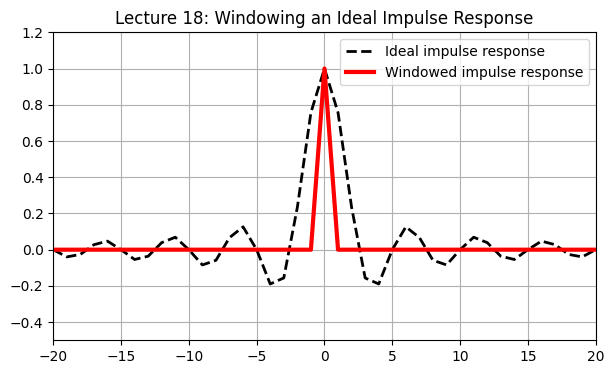

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 18: FIR Windowing Animation
# Same animation style as Lecture 9
# -----------------------------

# Time axis for impulse response
N = 41
n = np.arange(-(N//2), N//2 + 1)

# Ideal low-pass impulse response (sinc)
wc = 0.4 * np.pi
h_ideal = np.sinc((wc/np.pi) * n)

# Maximum window length
max_len = len(n)

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(min(n), max(n))
ax.set_ylim(-0.5, 1.2)
ax.grid(True)
ax.set_title("Lecture 18: Windowing an Ideal Impulse Response")

# Ideal impulse response (static reference)
ax.plot(n, h_ideal, 'k--', lw=2, label="Ideal impulse response")

# Animated windowed impulse response
h_line, = ax.plot([], [], 'r', lw=3, label="Windowed impulse response")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    h_win = np.zeros_like(h_ideal)
    
    center = max_len // 2
    half = frame // 2

    start = max(center - half, 0)
    end   = min(center + half + 1, max_len)

    h_win[start:end] = h_ideal[start:end]

    h_line.set_data(n, h_win)
    return (h_line,)

anim = FuncAnimation(fig, update,
                     frames=max_len,
                     interval=200)

HTML(anim.to_jshtml())

The central lobe of the impulse response appears first
More side lobes appear as the window grows
The impulse response becomes a better approximation of the infinite sinc
Ending with a finite‑length FIR filter